# Capstone Project: Predicting Diabetes Risk from Health Indicators

Diabetes is one of the most common chronic diseases in the world, and it places a major burden on both individuals and health systems. Earlier identification of people at risk can lead to earlier support, better health outcomes, and lower long-term treatment costs.

This notebook covers the first phase of my capstone project:

1. Import and understand the dataset
2. Clean and check the data
3. Carry out a detailed exploratory data analysis (EDA)
4. Summarise the most important findings before moving into feature engineering and modelling

The dataset I am using is the Centers for Disease Control and Prevention (CDC) Diabetes Health Indicators dataset from the UCI Machine Learning Repository, based on the CDC's BRFSS 2015 health survey.


# Business Context

Diabetes is a major public health issue because it is common, expensive to manage, and often linked to serious long-term health complications such as heart disease, stroke, kidney disease, and reduced quality of life.

One challenge with diabetes is that it is often caught too late. Clinical testing for diabetes is useful, but it can also be expensive and resource-intensive. Many people already provide useful health and lifestyle information through surveys, check-ups with their doctors, or digital health platforms. Being able to use that information could help identify people at higher risk of diabetes by evaluating their current lifestyle. That would also mean healthcare resources could be targeted more effectively toward those most at risk.

From a business and public health point of view, the value of this project is to help identify people who are at higher risk of developing diabetes, and to identify which features (predictors) have the most influence on that risk. Health and lifestyle factors are considered throughout this project. In practical terms, this is about screening triage rather than clinical diagnosis.


# Data Science Problem

My business question is:

Can health and lifestyle indicators be used to identify people who are at higher risk of diabetes, so that screening and prevention efforts can be targeted more effectively?

To answer my business question, I am treating the research task as a binary classification problem.

The target variable in this dataset is:

- 0 = no diabetes
- 1 = prediabetes or diabetes

One caveat before going further is that the CDC data only categorises someone as having no diabetes, or as having prediabetes or diabetes. There is no information on whether people in the diabetes group had type 1 or type 2 diabetes. In practice, many of the lifestyle and health indicators in this dataset are more closely linked with type 2 diabetes risk, so that is how I frame the screening problem for stakeholders, while keeping the label caveat clear.

So the data science version of my question becomes:

> To what extent can features such as BMI, blood pressure, cholesterol, general health, physical activity, and demographic factors help predict whether a person falls into the diabetes or prediabetes category?

This also means that I need to think carefully about modelling evaluation. In this project, a false negative would be more serious than a false positive, because missing someone who is at risk of diabetes could delay treatment or early intervention.


# Stakeholders

There are several stakeholders who could be interested in the outcomes of this project:

- Public health organisations - to better target diabetes prevention and screening programmes
- Doctors and clinicians - to help flag higher-risk patients earlier
- Health insurers and policy planners - to support prevention strategies that may reduce future costs
- Health app or digital platform developers - to build early risk screening tools into their products
- Individuals - to better understand which lifestyle and health factors are associated with higher diabetes risk

Overall, this project may help support better decision-making around prevention, early detection, and health education.


# About the Dataset

The dataset used in this project is the CDC Diabetes Health Indicators dataset from the UCI Machine Learning Repository:

[archive.ics.uci.edu](https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators)

### Dataset overview

- Source: CDC Behavioral Risk Factor Surveillance System (BRFSS) 2015
- Rows: 253,680 survey responses
- Features: 21 predictor variables
- Target: `Diabetes_binary`

### Target variable

- 0 = no diabetes
- 1 = prediabetes or diabetes

### What kind of variables are included?

The dataset includes variables related to:

- Medical conditions such as high blood pressure and high cholesterol
- Lifestyle factors such as smoking, fruit intake, vegetable intake, alcohol intake, and physical activity
- Healthcare access
- Self-reported health
- Demographic and socioeconomic indicators
- BMI


### Notes on the Target Variable and Survey Design

Before going further, there are two things I want to mention:

- Target variable construction: `Diabetes_binary` is not a raw single survey response. It is a combined label where 0 = no diabetes and 1 = prediabetes or diabetes. Prediabetes and diabetes are clinically different, but the UCI version of this dataset merges them into one class. As stated above, there is also no distinction between type 1 and type 2 diabetes within that class.
- Survey design: BRFSS is a weighted survey, meaning some respondents represent more of the population than others. The analysis in this notebook uses unweighted sample proportions (raw diabetes rates within the sample), not population-adjusted estimates.


# 1. Importing Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Importing the Dataset


In [2]:
from ucimlrepo import fetch_ucirepo

repo = fetch_ucirepo(id=891)

X = repo.data.features
y = repo.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [3]:
pd.set_option('display.max_colwidth', None)

data_dictionary = pd.DataFrame(repo.variables)

data_dictionary[['name', 'role', 'type', 'description']]

,name,role,type,description
0,ID,ID,Integer,Patient ID
1,Diabetes_binary,Target,Binary,0 = no diabetes 1 = prediabetes or diabetes
2,HighBP,Feature,Binary,0 = no high BP 1 = high BP
3,HighChol,Feature,Binary,0 = no high cholesterol 1 = high cholesterol
4,CholCheck,Feature,Binary,0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years
5,BMI,Feature,Integer,Body Mass Index
6,Smoker,Feature,Binary,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes
7,Stroke,Feature,Binary,(Ever told) you had a stroke. 0 = no 1 = yes
8,HeartDiseaseorAttack,Feature,Binary,coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes
9,PhysActivity,Feature,Binary,physical activity in past 30 days - not including job 0 = no 1 = yes


The data dictionary is useful because some of the columns use coded values rather than plain text labels. This is especially important for variables like age, education, income, and general health, because they are ordinal categories rather than continuous measurements.


# 3. Renaming Columns


In [4]:
# Rename columns to snake_case so they are easier to type and read
df = df.rename(columns={
    'HighBP': 'high_bp',
    'HighChol': 'high_chol',
    'CholCheck': 'chol_check',
    'BMI': 'bmi',
    'Smoker': 'smoker',
    'Stroke': 'stroke',
    'HeartDiseaseorAttack': 'heart_disease',
    'PhysActivity': 'phys_activity',
    'Fruits': 'fruits',
    'Veggies': 'veggies',
    'HvyAlcoholConsump': 'heavy_alcohol',
    'AnyHealthcare': 'any_healthcare',
    'NoDocbcCost': 'no_doc_cost',
    'GenHlth': 'general_health',
    'MentHlth': 'mental_health_days',
    'PhysHlth': 'physical_health_days',
    'DiffWalk': 'difficulty_walking',
    'Sex': 'sex',
    'Age': 'age',
    'Education': 'education',
    'Income': 'income',
    'Diabetes_binary': 'diabetes'
})

df.head()

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,no_doc_cost,general_health,mental_health_days,physical_health_days,difficulty_walking,sex,age,education,income,diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


# 4. Initial Data Checks


In [5]:
print("Shape of dataset:", df.shape)
print()

df.info()

Shape of dataset: (253680, 22)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   high_bp               253680 non-null  int64
 1   high_chol             253680 non-null  int64
 2   chol_check            253680 non-null  int64
 3   bmi                   253680 non-null  int64
 4   smoker                253680 non-null  int64
 5   stroke                253680 non-null  int64
 6   heart_disease         253680 non-null  int64
 7   phys_activity         253680 non-null  int64
 8   fruits                253680 non-null  int64
 9   veggies               253680 non-null  int64
 10  heavy_alcohol         253680 non-null  int64
 11  any_healthcare        253680 non-null  int64
 12  no_doc_cost           253680 non-null  int64
 13  general_health        253680 non-null  int64
 14  mental_health_days    253680 non-null  int64
 15  ph

In [6]:
info_df = pd.DataFrame({
    "data_type": df.dtypes,
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique()
})

info_df

,data_type,missing_values,unique_values
high_bp,int64,0,2
high_chol,int64,0,2
chol_check,int64,0,2
bmi,int64,0,84
smoker,int64,0,2
stroke,int64,0,2
heart_disease,int64,0,2
phys_activity,int64,0,2
fruits,int64,0,2
veggies,int64,0,2


In [7]:
df.describe().round(2)

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,no_doc_cost,general_health,mental_health_days,physical_health_days,difficulty_walking,sex,age,education,income,diabetes
count,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,0.81,...,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05,0.14
std,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,0.39,...,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07,0.35
min,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00
25%,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00,0.00
50%,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00,0.00
75%,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,1.00,...,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00,0.00
max,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00,1.00


### Initial observations

At this stage, a few things stand out:

- There are no missing values
- Most variables are stored as integers
- Many of the columns are binary variables with values 0 and 1
- Some variables such as age, education, income, and general health are coded ordinal categories

This already suggests that I will need a mix of different visualisations rather than one single approach for every feature.


# 5. Checking for Duplicates


In [8]:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count, "(" + str(round(duplicate_percent, 2)) + "% of the dataset)")


Duplicate rows: 24206 (9.54% of the dataset)


In [9]:
df = df.drop_duplicates()
df = df.reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (229474, 22)


### Duplicate row decision

I found 24,206 duplicate rows, which is about 9.54% of the dataset.

Because this dataset comes from survey responses and does not include a unique ID column, repeated response patterns are plausible and is what I found. However, keeping duplicate rows would give extra weight to the same duplicated responses, so I decided to remove duplicates before continuing with the EDA.

This leaves me with 229,474 rows, which is still a large dataset and contains enough data to carry out appropriate analysis.

# 6. Checking Feature Ranges


In [10]:
# Quick range checks for key coded variables
# Expected ranges come from the data dictionary / BRFSS coding
range_checks = {
    'bmi': (10, 100),
    'general_health': (1, 5),
    'mental_health_days': (0, 30),
    'physical_health_days': (0, 30),
    'age': (1, 13),
    'education': (1, 6),
    'income': (1, 8)
}

for column in range_checks:
    min_value = range_checks[column][0]
    max_value = range_checks[column][1]

    actual_min = df[column].min()
    actual_max = df[column].max()

    too_low = df[column] < min_value
    too_high = df[column] > max_value
    out_of_range = df[too_low | too_high].shape[0]

    print(
        column + ":",
        "min =", actual_min,
        "max =", actual_max,
        "out of range values =", out_of_range
    )

bmi: min = 12 max = 98 out of range values = 0
general_health: min = 1 max = 5 out of range values = 0
mental_health_days: min = 0 max = 30 out of range values = 0
physical_health_days: min = 0 max = 30 out of range values = 0
age: min = 1 max = 13 out of range values = 0
education: min = 1 max = 6 out of range values = 0
income: min = 1 max = 8 out of range values = 0


The key coded variables all fall within their expected ranges, so there do not appear to be obvious coding issues in the dataset. BMI includes some very high values, but these are still possible in real-world data, so I will keep them for now and look at the distribution more carefully during the EDA.


# 7. Grouping Features by Type


In [11]:
# Group features by type so we can explore them in different ways later
binary_cols = [
    'high_bp', 'high_chol', 'chol_check', 'smoker', 'stroke',
    'heart_disease', 'phys_activity', 'fruits', 'veggies',
    'heavy_alcohol', 'any_healthcare', 'no_doc_cost',
    'difficulty_walking', 'sex'
]

ordinal_cols = ['general_health', 'age', 'education', 'income']

numeric_cols = ['bmi', 'mental_health_days', 'physical_health_days']

print("Binary columns:")
print(binary_cols)
print()

print("Ordinal columns:")
print(ordinal_cols)
print()

print("Numeric columns:")
print(numeric_cols)

Binary columns:
['high_bp', 'high_chol', 'chol_check', 'smoker', 'stroke', 'heart_disease', 'phys_activity', 'fruits', 'veggies', 'heavy_alcohol', 'any_healthcare', 'no_doc_cost', 'difficulty_walking', 'sex']

Ordinal columns:
['general_health', 'age', 'education', 'income']

Numeric columns:
['bmi', 'mental_health_days', 'physical_health_days']


I grouped the variables this way because each type is better explored with different methods:

- Binary features are easier to compare using countplots and group means
- Ordinal features are better treated as ordered categories
- Numeric features can be explored through histograms, boxplots, skewness, and summary statistics

Organising the features this way makes the EDA easier to follow and easier to explain.


# 8. Exploratory Data Analysis

The goal of my EDA was not just to create visualisations, but to understand which health, lifestyle, and socioeconomic factors showed the clearest relationship with diabetes before moving into feature engineering and modelling.

## 8.1 Target Variable Distribution


In [12]:
diabetes_counts = df['diabetes'].value_counts().sort_index()
diabetes_percent = df['diabetes'].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'count': diabetes_counts,
    'percentage': diabetes_percent.round(2)
})

target_summary.index = ['No diabetes (0)', 'Prediabetes/Diabetes (1)']
target_summary

,count,percentage
No diabetes (0),194377,84.71
Prediabetes/Diabetes (1),35097,15.29


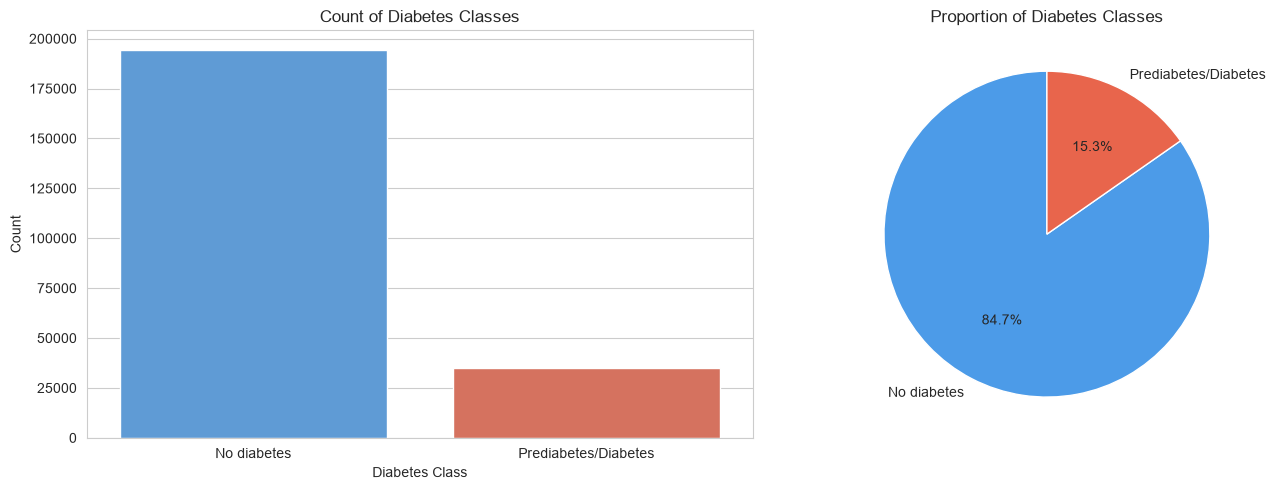

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    x='diabetes',
    data=df,
    palette=['#4C9BE8', '#E8654C'],
    ax=axes[0]
)
axes[0].set_title("Count of Diabetes Classes")
axes[0].set_xlabel("Diabetes Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(['No diabetes', 'Prediabetes/Diabetes'])

axes[1].pie(
    diabetes_counts,
    labels=['No diabetes', 'Prediabetes/Diabetes'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C9BE8', '#E8654C']
)
axes[1].set_title("Proportion of Diabetes Classes")

plt.tight_layout()
plt.show()

### Observation

The target variable is clearly imbalanced. 84.7% of the survey respondents fall into the no diabetes class, while 15.3% fall into the prediabetes/diabetes class.

This is important for my modelling. Using accuracy alone as a performance metric would be misleading, because a model could score high accuracy simply by predicting the majority class. When I evaluate my models, I will therefore look at other metrics such as recall, precision, F1-score, and ROC AUC, with particular attention to recall and false negatives.


## 8.2 Exploring the Numeric Features


In [14]:
df[numeric_cols].describe().round(2)

,bmi,mental_health_days,physical_health_days
count,229474.00,229474.00,229474.00
mean,28.69,3.51,4.68
std,6.79,7.72,9.05
min,12.00,0.00,0.00
25%,24.00,0.00,0.00
50%,27.00,0.00,0.00
75%,32.00,2.00,4.00
max,98.00,30.00,30.00


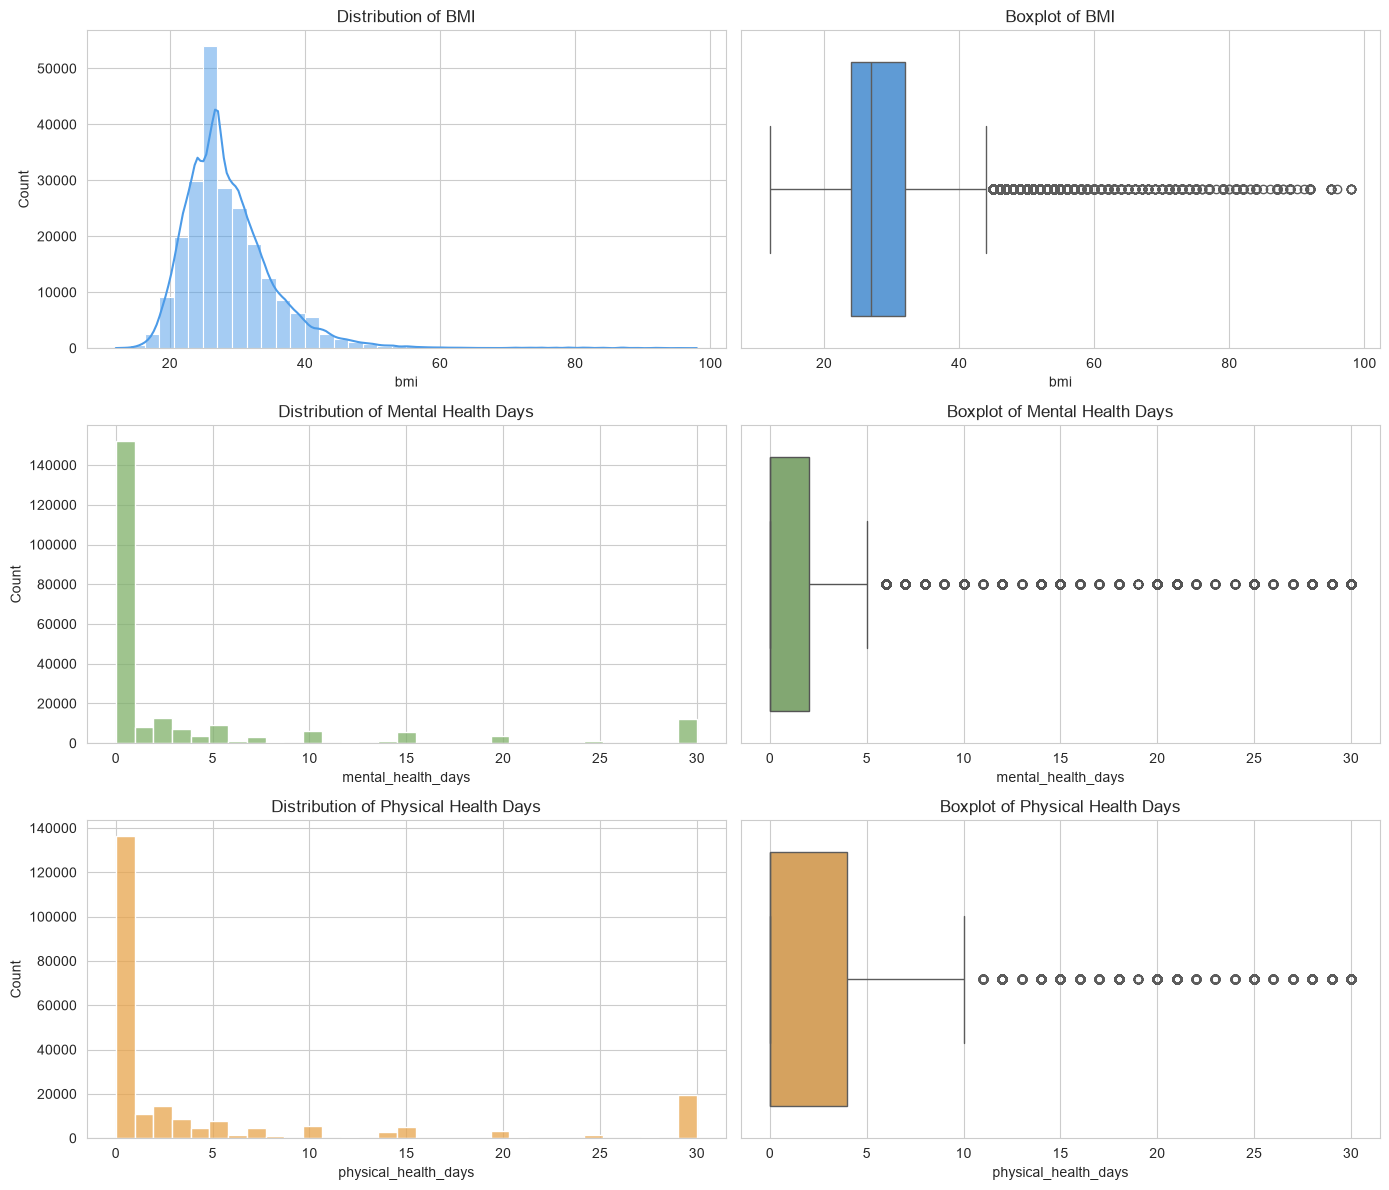

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

sns.histplot(df['bmi'], bins=40, kde=True, color='#4C9BE8', ax=axes[0, 0])
axes[0, 0].set_title("Distribution of BMI")

sns.boxplot(x=df['bmi'], color='#4C9BE8', ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of BMI")

sns.histplot(df['mental_health_days'], bins=31, kde=False, color='#7FB069', ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Mental Health Days")

sns.boxplot(x=df['mental_health_days'], color='#7FB069', ax=axes[1, 1])
axes[1, 1].set_title("Boxplot of Mental Health Days")

sns.histplot(df['physical_health_days'], bins=31, kde=False, color='#E8A44C', ax=axes[2, 0])
axes[2, 0].set_title("Distribution of Physical Health Days")

sns.boxplot(x=df['physical_health_days'], color='#E8A44C', ax=axes[2, 1])
axes[2, 1].set_title("Boxplot of Physical Health Days")

plt.tight_layout()
plt.show()

In [16]:
for column in numeric_cols:
    skew_value = df[column].skew()
    print(column + ': skewness =', round(skew_value, 2))

bmi: skewness = 2.06
mental_health_days: skewness = 2.54
physical_health_days: skewness = 2.04


### Observation

The numeric variables are not normally distributed.

- BMI is right-skewed, with some high values creating a longer upper tail
- Mental health days and physical health days are both heavily concentrated at 0, which means many respondents reported no poor health days
- Both health-day variables also show a spike near 30, which likely reflects people reporting poor health for most or all days in a month

This tells me that these features are not evenly distributed. That is important for both interpretation and later model preparation.


In [17]:
# Check for potential BMI outliers using the IQR method
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

below_lower = df['bmi'] < lower_bound
above_upper = df['bmi'] > upper_bound
bmi_outliers = df[below_lower | above_upper]

outlier_percent = (len(bmi_outliers) / len(df)) * 100

print("IQR bounds: [", round(lower_bound, 1), ",", round(upper_bound, 1), "]")
print("Number of BMI outliers:", len(bmi_outliers), "(", round(outlier_percent, 2), "% of the dataset)")
print("Max BMI in dataset:", df['bmi'].max())

IQR bounds: [ 12.0 , 44.0 ]
Number of BMI outliers: 5638 ( 2.46 % of the dataset)
Max BMI in dataset: 98


### BMI Outlier Decision

Using the IQR method, a small percentage of respondents fall outside the typical BMI range. These extreme values are plausible, as BMI values above 60 do occur in a clinical setting. Given that the data is from the United States and comes from a large population survey, there will be people who are severely obese and have BMI values above 60.

Decision: I decided to keep the large BMI values rather than removing them. The outliers represent a small group within the BMI data. I will come back to this decision during feature engineering. I will need to consider which approach is appropriate there, as models such as logistic regression and other linear models are sensitive to outliers.


## 8.3 BMI Categories


In [18]:
# Create BMI categories using standard BMI classification ranges
bmi_bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
bmi_labels = [
    'Underweight',
    'Normal weight',
    'Overweight',
    'Obese Class I',
    'Obese Class II',
    'Obese Class III'
]

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
)

df[['bmi', 'bmi_category']].sort_values('bmi').head(15)

,bmi,bmi_category
216828,12,Underweight
126181,12,Underweight
192325,12,Underweight
162771,12,Underweight
92077,12,Underweight
47643,12,Underweight
37416,13,Underweight
38933,13,Underweight
190473,13,Underweight
116933,13,Underweight


### Observation

I decided to group BMI into standard clinical categories so it would be easier to interpret than the raw values alone. I used the following classes:

- Underweight: BMI less than 18.5
- Normal weight: BMI 18.5 to 24.9
- Overweight: BMI 25 to 29.9
- Obese Class I: BMI 30 to 34.9
- Obese Class II: BMI 35 to 39.9
- Obese Class III: BMI 40 and above

I used `right=False` in `pd.cut()` so that the lower boundary is included in the next category. This means a BMI of 25 is correctly grouped as Overweight, and a BMI of 40 is correctly grouped as Obese Class III.

This makes the grouped BMI feature more accurate and easier to explain in the EDA.


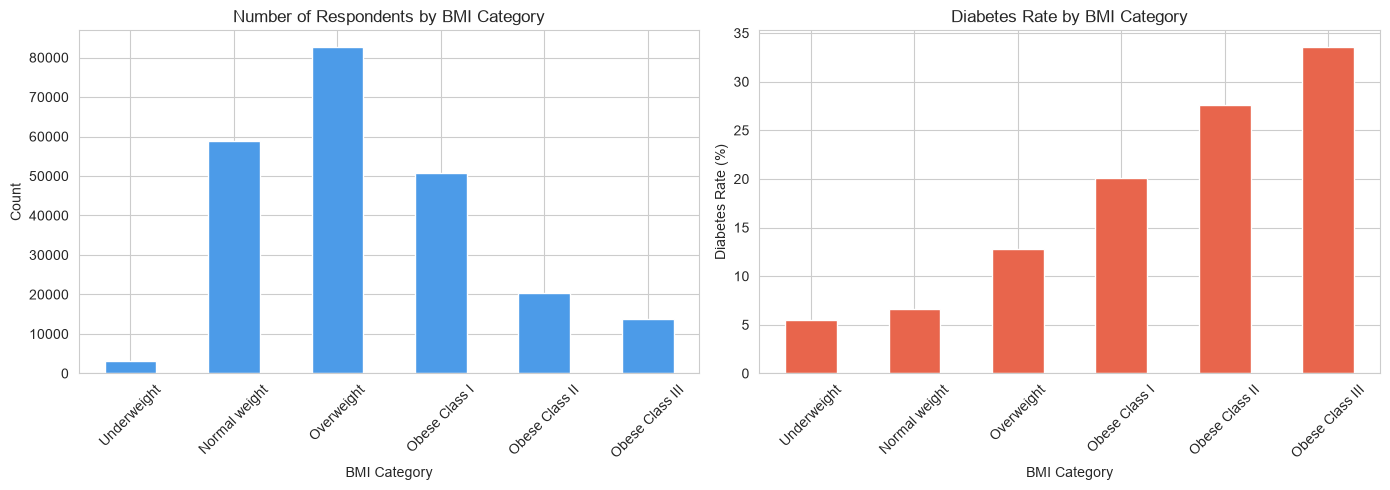

In [19]:
bmi_count = df['bmi_category'].value_counts()
bmi_count = bmi_count.reindex(bmi_labels)

bmi_diabetes_rate = df.groupby('bmi_category')['diabetes'].mean() * 100
bmi_diabetes_rate = bmi_diabetes_rate.reindex(bmi_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bmi_count.plot(kind='bar', color='#4C9BE8', ax=axes[0])
axes[0].set_title("Number of Respondents by BMI Category")
axes[0].set_xlabel("BMI Category")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

bmi_diabetes_rate.plot(kind='bar', color='#E8654C', ax=axes[1])
axes[1].set_title("Diabetes Rate by BMI Category")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Diabetes Rate (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Observation

The first bar chart shows how the survey respondents are distributed across the different BMI groups. Over 80,000 of the respondents fall into the overweight BMI class. The second chart is more valuable for this project. It shows the percentage of people who are prediabetic or diabetic within each BMI class.

The graph shows a clear trend: as BMI increases, the diabetes rate also increases. These clinical BMI classes will be useful when I move on to selecting features for modelling.


## 8.4 Exploring the Binary Features


In [20]:
no_diabetes_rows = df[df['diabetes'] == 0]
diabetes_rows = df[df['diabetes'] == 1]

binary_means_no_diabetes = no_diabetes_rows[binary_cols].mean()
binary_means_diabetes = diabetes_rows[binary_cols].mean()

binary_comparison = pd.DataFrame({
    'no_diabetes_rate': binary_means_no_diabetes,
    'diabetes_rate': binary_means_diabetes
})

binary_comparison['difference'] = (
    binary_comparison['diabetes_rate'] - binary_comparison['no_diabetes_rate']
)
binary_comparison = binary_comparison.sort_values('difference', ascending=False)

binary_comparison.round(3)

,no_diabetes_rate,diabetes_rate,difference
high_bp,0.401,0.752,0.352
high_chol,0.401,0.669,0.269
difficulty_walking,0.152,0.374,0.222
heart_disease,0.082,0.224,0.142
smoker,0.456,0.519,0.063
stroke,0.036,0.093,0.057
sex,0.432,0.477,0.045
chol_check,0.953,0.993,0.040
no_doc_cost,0.090,0.107,0.016
any_healthcare,0.944,0.959,0.016


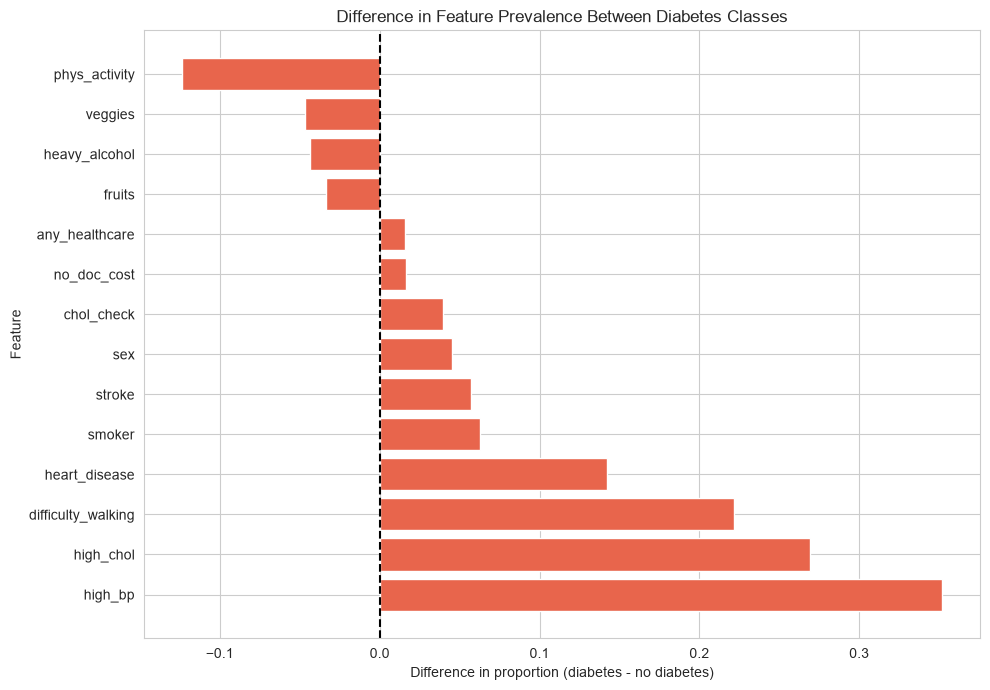

In [21]:
plt.figure(figsize=(10, 7))

plt.barh(
    binary_comparison.index,
    binary_comparison['difference'],
    color='#E8654C'
)
plt.title("Difference in Feature Prevalence Between Diabetes Classes")
plt.xlabel("Difference in proportion (diabetes - no diabetes)")
plt.ylabel("Feature")
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

### Observation

The graphs above help illustrate which binary features separate the diabetes and non-diabetes groups most clearly.

From the table and graphs, the largest differences between those with diabetes and those without diabetes appear in high blood pressure, high cholesterol, difficulty walking, heart disease, and stroke.

In contrast, physical activity is less common within the diabetic group, which suggests that people who are physically active may be at lower risk of diabetes. Some features, such as fruit and vegetable intake, do not show much difference between the groups.

From the table and graphs, I am starting to see that predicting diabetes risk is multifactorial. Multiple different features (predictors) influence whether someone will be at risk. This is an important consideration when I move on to modelling.


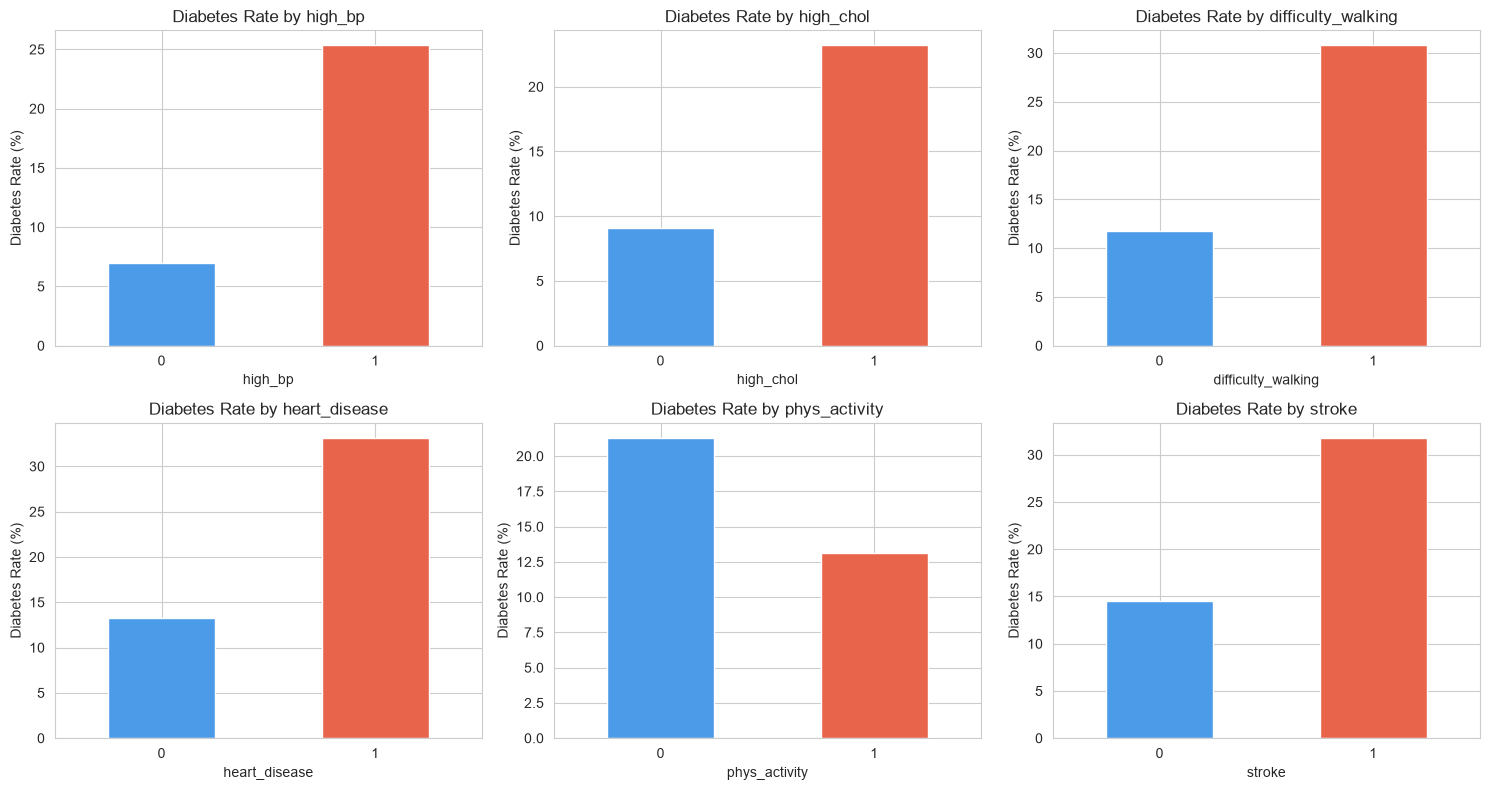

In [22]:
key_binary_features = [
    'high_bp',
    'high_chol',
    'difficulty_walking',
    'heart_disease',
    'phys_activity',
    'stroke'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, column in enumerate(key_binary_features):
    diabetes_rate = df.groupby(column)['diabetes'].mean() * 100

    diabetes_rate.plot(kind='bar', ax=axes[i], color=['#4C9BE8', '#E8654C'])
    axes[i].set_title("Diabetes Rate by " + column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Diabetes Rate (%)")
    axes[i].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

### Observation

These plots show how the diabetes rate changes across different binary classes. I chose these classes based on the tables and graphs above.

As suggested earlier, respondents who had high blood pressure, high cholesterol, heart disease, difficulty walking, or a stroke history had a much higher diabetes rate than individuals without those conditions.

The physical activity chart moves in the opposite direction, with more active respondents showing a lower diabetes rate. This is useful because it shows that not all variables increase diabetes risk.


## 8.5 Exploring Sex as a Feature


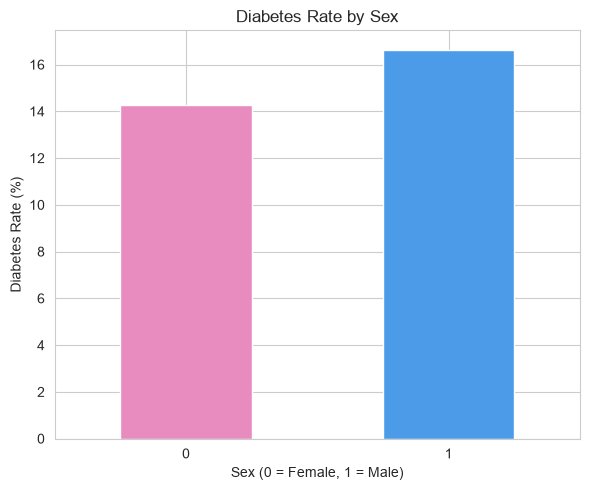

sex
0    14.252418
1    16.625810
Name: diabetes, dtype: float64

In [23]:
# Diabetes rate by sex (0 = female, 1 = male in this dataset)
sex_diabetes_rate = df.groupby('sex')['diabetes'].mean() * 100

plt.figure(figsize=(6, 5))
sex_diabetes_rate.plot(kind='bar', color=['#E88CC0', '#4C9BE8'])
plt.title("Diabetes Rate by Sex")
plt.xlabel("Sex (0 = Female, 1 = Male)")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

sex_diabetes_rate

### Observation

The rate of diabetes differs slightly by sex. However, the difference is much smaller than for the variables below. This suggests that whether someone is male or female plays only a minor role in diabetes risk. Since my dataset is so large, I will still keep sex as a variable in the modelling stage, because even small effects may influence the target variable and may also be useful in showing how sex combines with other variables.


## 8.6 Exploring the Ordinal Features

Ordinal data is a type of categorical data where the categories have a meaningful order, but the exact differences between them are unknown or unequal.


In [24]:
# Create readable labels for age and general health
age_labels = {
    1: '18-24',
    2: '25-29',
    3: '30-34',
    4: '35-39',
    5: '40-44',
    6: '45-49',
    7: '50-54',
    8: '55-59',
    9: '60-64',
    10: '65-69',
    11: '70-74',
    12: '75-79',
    13: '80+'
}

general_health_labels = {
    1: 'Excellent',
    2: 'Very good',
    3: 'Good',
    4: 'Fair',
    5: 'Poor'
}

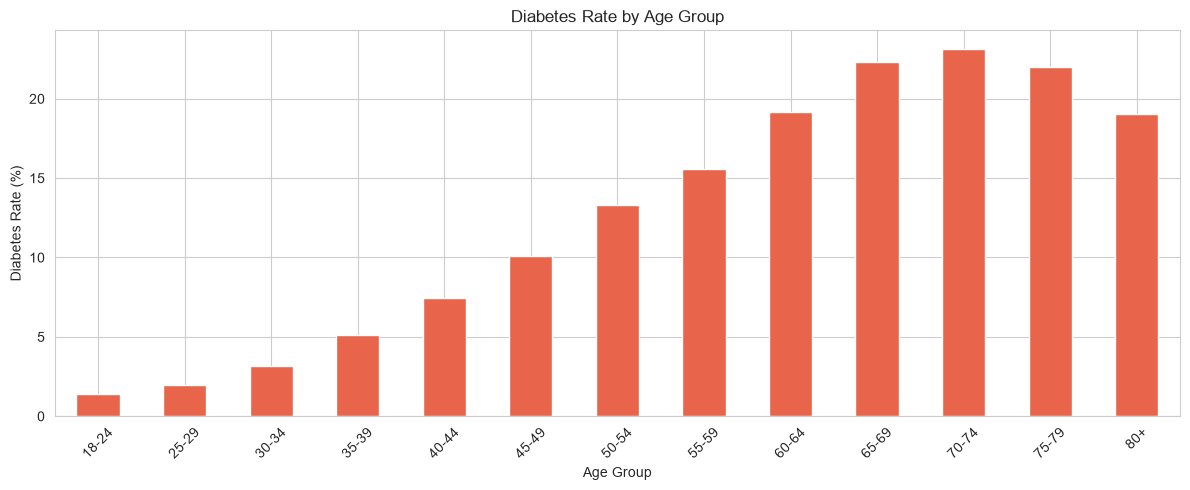

In [25]:
age_diabetes_rate = df.groupby('age')['diabetes'].mean() * 100

age_diabetes_rate.index = age_diabetes_rate.index.map(age_labels)

plt.figure(figsize=(12, 5))
age_diabetes_rate.plot(kind='bar', color='#E8654C')
plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

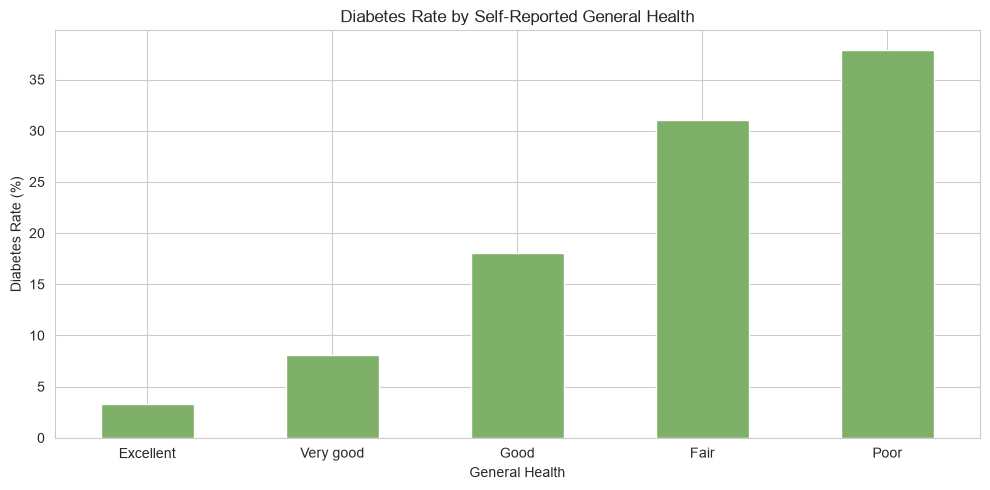

In [26]:
# Diabetes rate by self-reported general health
general_health_diabetes_rate = df.groupby('general_health')['diabetes'].mean() * 100
general_health_diabetes_rate.index = general_health_diabetes_rate.index.map(general_health_labels)

plt.figure(figsize=(10, 5))
general_health_diabetes_rate.plot(kind='bar', color='#7FB069')
plt.title("Diabetes Rate by Self-Reported General Health")
plt.xlabel("General Health")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


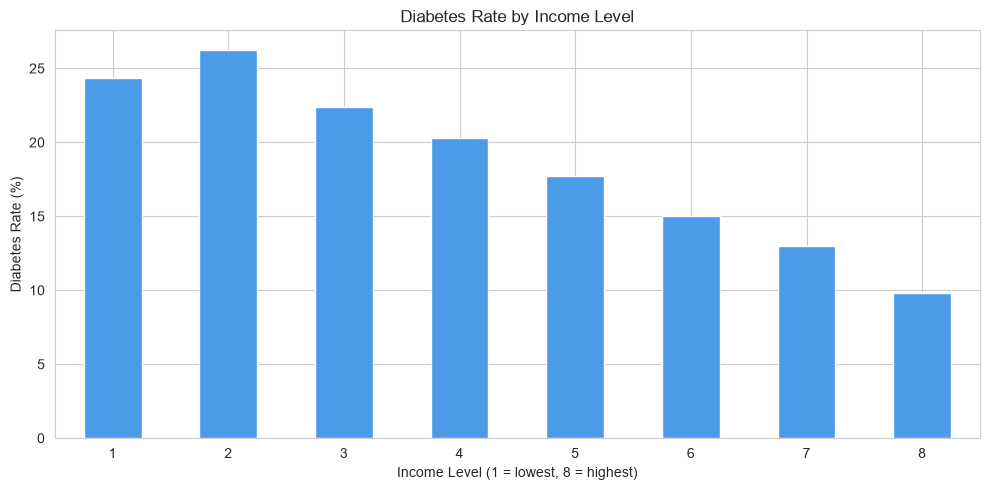

In [27]:
# Diabetes rate by income level
income_diabetes_rate = df.groupby('income')['diabetes'].mean() * 100

plt.figure(figsize=(10, 5))
income_diabetes_rate.plot(kind='bar', color='#4C9BE8')
plt.title("Diabetes Rate by Income Level")
plt.xlabel("Income Level (1 = lowest, 8 = highest)")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


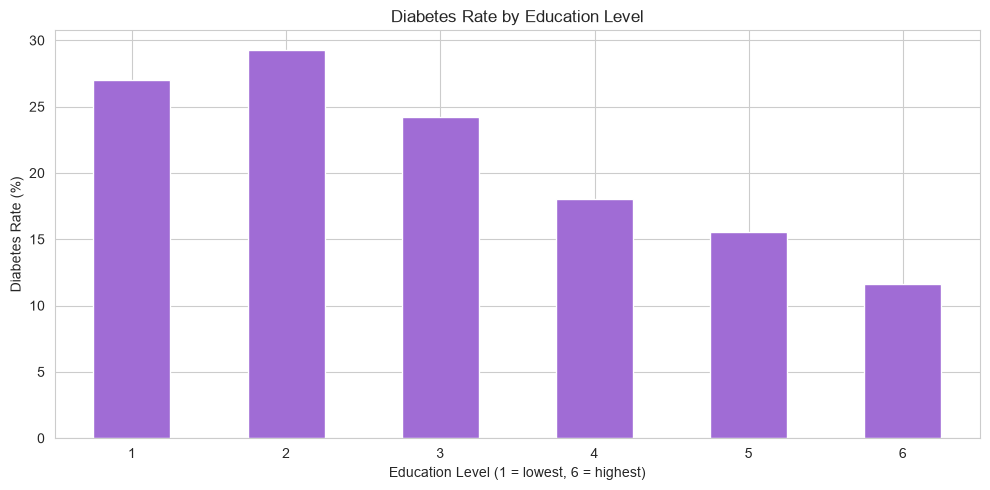

In [28]:
# Diabetes rate by education level
education_diabetes_rate = df.groupby('education')['diabetes'].mean() * 100

plt.figure(figsize=(10, 5))
education_diabetes_rate.plot(kind='bar', color='#A06CD5')
plt.title("Diabetes Rate by Education Level")
plt.xlabel("Education Level (1 = lowest, 6 = highest)")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

The ordinal variables show some of the clearest trends in the notebook.

The graphs show a clear pattern: as an individual's age increases, their rate of diabetes also increases. Most of the skew is toward the upper end, which shows that older age groups are more at risk of being diabetic. The general health chart also shows that those who report poorer health were more likely to be prediabetic or diabetic.

The graphs also show some socio-economic patterns. Individuals who reported lower income and education had higher diabetes rates. This supports what I said earlier in the notebook: diabetes risk is multifactorial and linked to multiple factors. That is important for me to consider when modelling.


## 8.7 Relationship Between Age and BMI


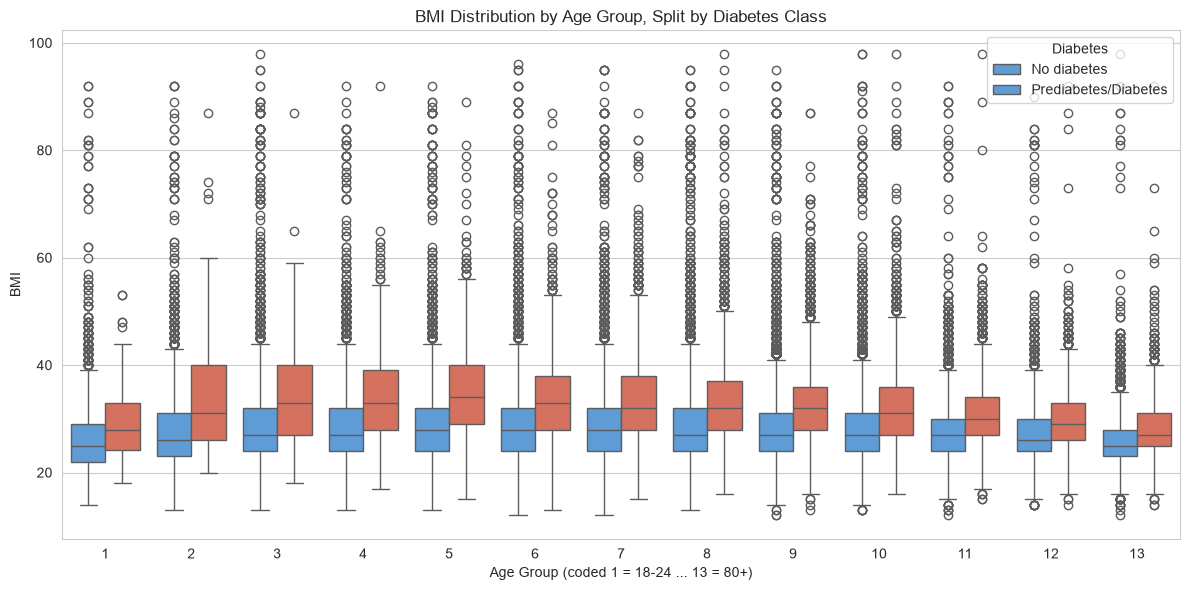

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='age',
    y='bmi',
    hue='diabetes',
    palette=['#4C9BE8', '#E8654C']
)

plt.title("BMI Distribution by Age Group, Split by Diabetes Class")
plt.xlabel("Age Group (coded 1 = 18-24 ... 13 = 80+)")
plt.ylabel("BMI")
plt.legend(title='Diabetes', labels=['No diabetes', 'Prediabetes/Diabetes'])
plt.tight_layout()
plt.show()

### Observation

Since `age` is a coded ordinal variable rather than a continuous variable, a boxplot represents this relationship more accurately than a scatterplot would. A scatterplot of age versus BMI would create artificial vertical stripes at each age code rather than showing a real trend.

The boxplot shows that median BMI is consistently higher in the diabetes/prediabetes group across almost every age band, and this gap holds fairly steadily from the 30s through to the oldest age groups. This supports what was seen earlier when looking at BMI and age separately, and suggests diabetes risk is probably influenced by a combination of features rather than a single variable alone.


## 8.8 BMI and Age Combined - Diabetes Rate Heatmap


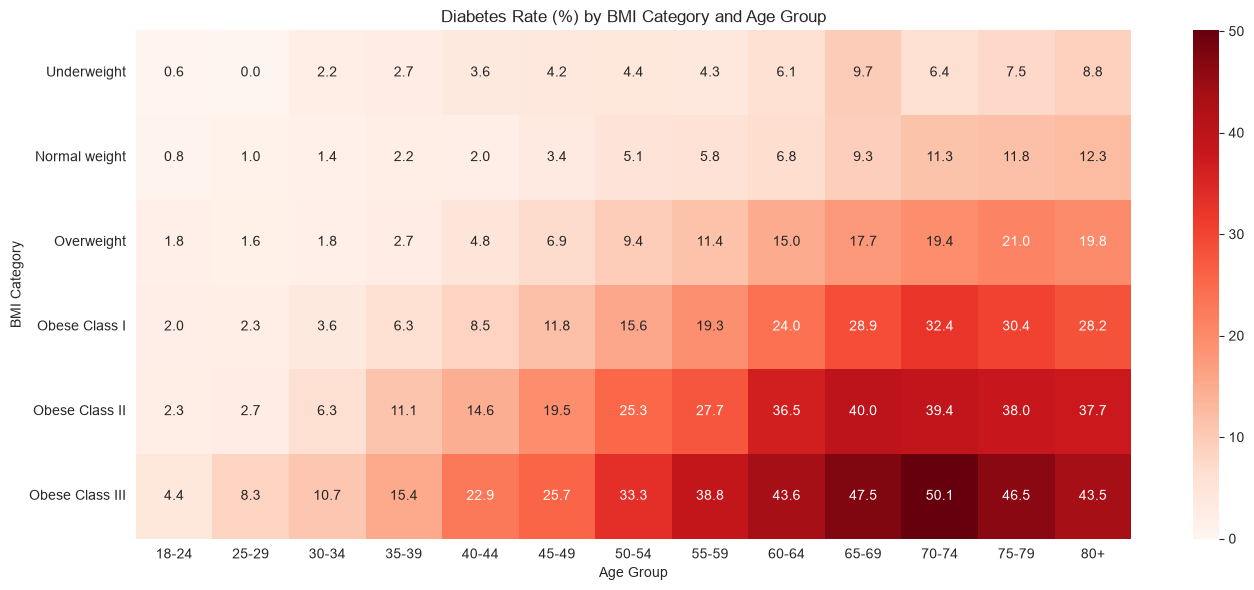

In [30]:
bmi_age_diabetes = pd.pivot_table(
    df,
    values='diabetes',
    index='bmi_category',
    columns='age',
    aggfunc='mean'
) * 100

new_columns = []
for col in bmi_age_diabetes.columns:
    new_columns.append(age_labels[col])
bmi_age_diabetes.columns = new_columns

plt.figure(figsize=(14, 6))
sns.heatmap(bmi_age_diabetes, annot=True, fmt='.1f', cmap='Reds')
plt.title("Diabetes Rate (%) by BMI Category and Age Group")
plt.xlabel("Age Group")
plt.ylabel("BMI Category")
plt.tight_layout()
plt.show()

### Observation

This heatmap is useful because it shows how diabetes risk changes when two important features are considered together.

The highest diabetes rates appear in the combination of higher BMI categories and older age groups.

This also supports the broader idea that diabetes risk becomes stronger when multiple features are considered together.


## 8.9 Creating an Exploratory Risk Score


In [31]:
# Simple exploratory risk score: count of selected health risks
risk_features = [
    'high_bp',
    'high_chol',
    'heart_disease',
    'difficulty_walking',
    'stroke'
]

df['risk_factor_count'] = df[risk_features].sum(axis=1)

df[['risk_factor_count']].describe()

,risk_factor_count
count,229474.000000
mean,1.229887
std,1.146698
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


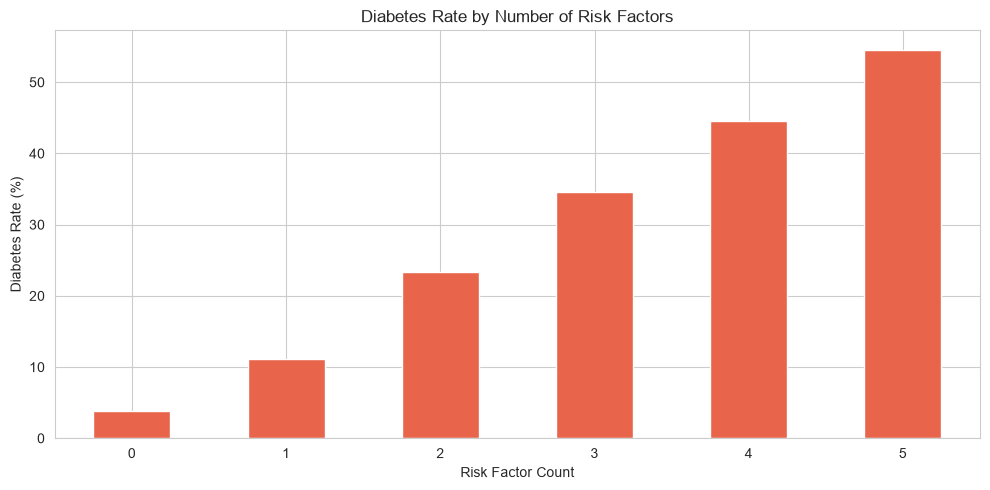

In [32]:
# Calculate diabetes rate for each risk factor count
risk_count_diabetes_rate = df.groupby('risk_factor_count')['diabetes'].mean() * 100

plt.figure(figsize=(10, 5))
risk_count_diabetes_rate.plot(kind='bar', color='#E8654C')
plt.title("Diabetes Rate by Number of Risk Factors")
plt.xlabel("Risk Factor Count")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

After doing the EDA above, I decided to create a feature combining five health-related factors into one variable to see whether this would show clear patterns in the data.

It combines five important health-related indicators:

- high blood pressure
- high cholesterol
- heart disease
- difficulty walking
- stroke

The chart above shows a very clear pattern. As the number of risk factors increases, the diabetes rate also increases.

This suggests that diabetes risk is not just related to one feature on its own. Instead, the risk appears to increase more when a combination of features is present. Therefore, when I do my modelling I must consider a range of features for analysis.

Caveat: because `risk_factor_count` is engineered from `high_bp`, `high_chol`, `heart_disease`, `difficulty_walking`, and `stroke`, its strong relationship with diabetes later in the correlation analysis is partly mechanical. In modelling, I will therefore see how models perform with and without this feature.


## 8.10 Correlation Analysis


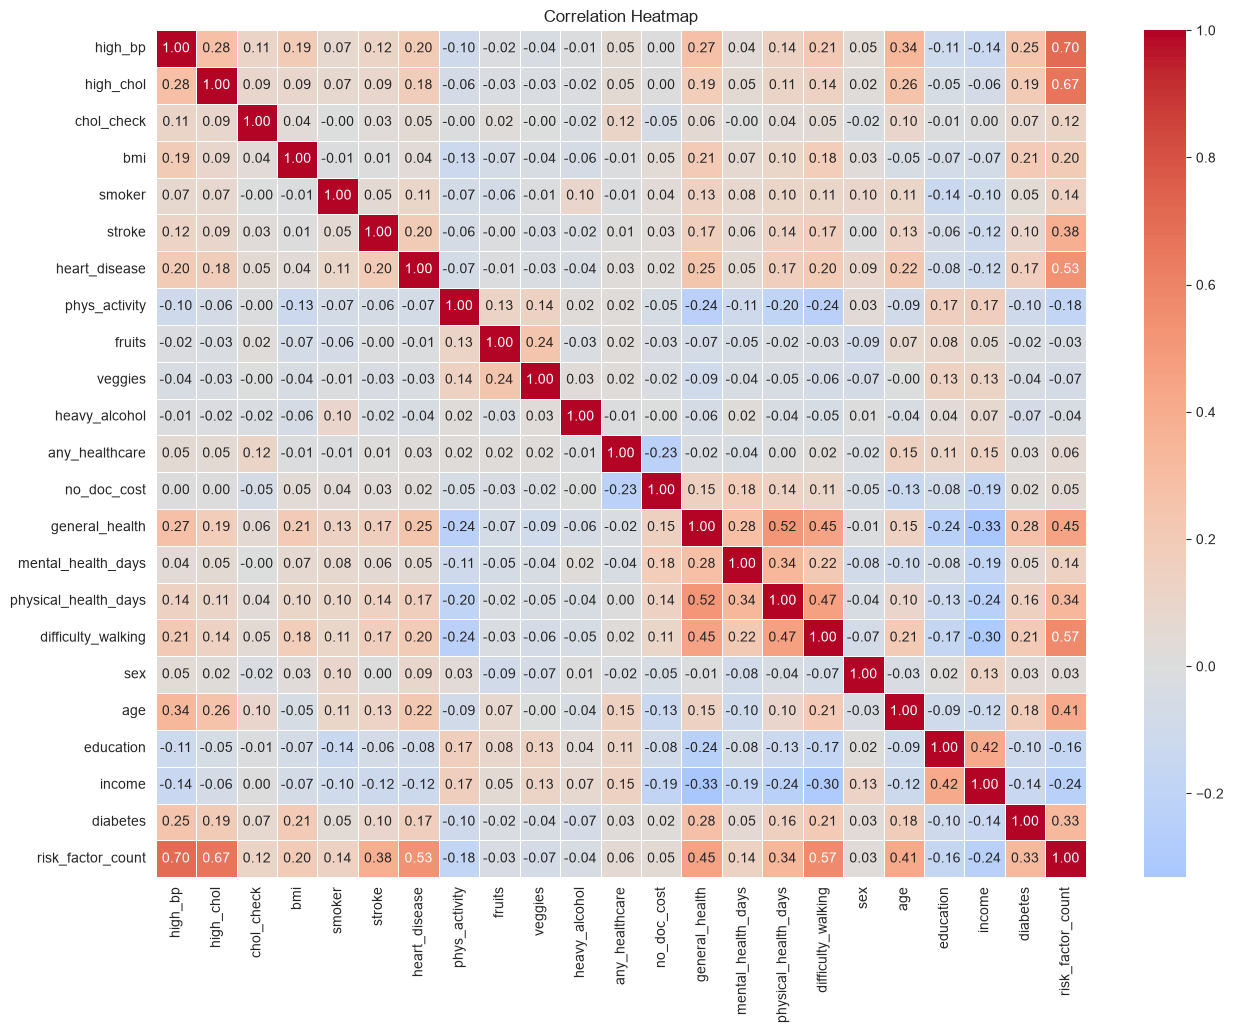

In [33]:
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(15, 11))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap helps show which numeric variables are correlated with my target variable (diabetes).

The variables showing strong positive relationships with diabetes include `general_health`, `high_bp`, `bmi`, `difficulty_walking`, `high_chol`, and `age`. This supports the patterns already seen in the earlier charts. Diabetes is also correlated with `risk_factor_count` (r = 0.33), which makes sense given the reasons discussed above.


In [34]:
target_correlation = correlation_matrix['diabetes'].sort_values(ascending=False)

target_correlation_filtered = target_correlation.drop(['diabetes', 'risk_factor_count'])

target_correlation_filtered.to_frame(name='correlation_with_diabetes')

,correlation_with_diabetes
general_health,0.276940
high_bp,0.254318
difficulty_walking,0.205302
bmi,0.205086
high_chol,0.194944
age,0.177263
heart_disease,0.168213
physical_health_days,0.156211
stroke,0.099193
chol_check,0.072523


### Observation

This chart focuses only on the original dataset features and shows which of them have the strongest linear relationship with the diabetes target.

The strongest positive relationships appear in:

- general_health
- high_bp
- bmi
- difficulty_walking
- high_chol
- age

Negative relationships appear in variables such as:

- income
- education
- phys_activity

I removed `risk_factor_count` from this chart because it is a derived feature I created during the EDA, not one of the original variables in the dataset. This makes the comparison clearer and keeps the focus on the original features only.


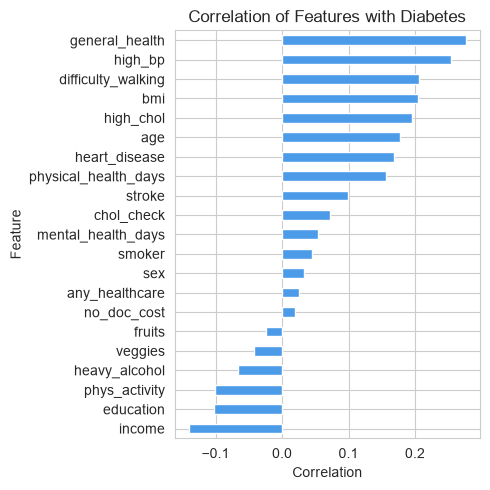

In [35]:
target_correlation_filtered = target_correlation.drop(['diabetes', 'risk_factor_count'])

plt.figure(figsize=(5, 5))
target_correlation_filtered.sort_values().plot(kind='barh', color='#4C9BE8')

plt.title("Correlation of Features with Diabetes")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 8.11 Checking for Multicollinearity (VIF)


The correlation heatmap above shows how each feature relates to the target variable, but it does not tell me how highly correlated the features are with each other. I want to check whether there is multicollinearity between the variables, as this can distort coefficients when predictors overlap.

I decided to use the Variance Inflation Factor (VIF) to check multicollinearity. From my research, VIF values above 5 to 10 suggest a feature has significant overlap with other predictors.


In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_features = binary_cols + ordinal_cols + numeric_cols
vif_df = add_constant(df[vif_features])

vif_rows = []
for i in range(vif_df.shape[1]):
    feature_name = vif_df.columns[i]
    vif_value = variance_inflation_factor(vif_df.values, i)
    vif_rows.append({
        'feature': feature_name,
        'VIF': vif_value
    })

vif_results = pd.DataFrame(vif_rows)

vif_results = vif_results[vif_results['feature'] != 'const']
vif_results = vif_results.sort_values('VIF', ascending=False)

vif_results

,feature,VIF
15,general_health,1.716096
21,physical_health_days,1.594297
13,difficulty_walking,1.511628
18,income,1.430313
16,age,1.353317
1,high_bp,1.301200
17,education,1.272080
20,mental_health_days,1.221587
6,heart_disease,1.167062
2,high_chol,1.158112


### Observation

Most features show low to moderate VIF values, meaning they do not overlap heavily with each other. A few features related to overall health status (`general_health`, `difficulty_walking`, `physical_health_days`) tend to show higher VIF than the rest of the variables, which makes sense since they are all capturing overlapping aspects of a person's health condition.

None of the values reach a level that would be a serious concern for tree-based models (such as random forest or gradient boosting). If I use a linear model like logistic regression during modelling, I will keep an eye on these features and consider whether to drop, combine, or regularise around them (for example with L2/ridge-style regularisation).


## 8.12 Statistical Significance Checks


In [37]:
def cramers_v(confusion_matrix):
    # Chi-square statistic from the contingency table
    chi2 = stats.chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    r = confusion_matrix.shape[0]
    k = confusion_matrix.shape[1]

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


chi_square_results = []

for column in binary_cols:
    contingency_table = pd.crosstab(df[column], df['diabetes'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    effect_size = cramers_v(contingency_table)

    chi_square_results.append({
        'feature': column,
        'chi2_statistic': chi2,
        'p_value': p_value,
        'cramers_v': effect_size
    })

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df = chi_square_df.sort_values('cramers_v', ascending=False)

chi_square_df

,feature,chi2_statistic,p_value,cramers_v
0,high_bp,14840.421805,0.000000e+00,0.254306
12,difficulty_walking,9670.630180,0.000000e+00,0.205287
1,high_chol,8719.656978,0.000000e+00,0.194932
5,heart_disease,6491.585745,0.000000e+00,0.168193
6,phys_activity,2312.703694,0.000000e+00,0.100391
4,stroke,2256.534055,0.000000e+00,0.099164
2,chol_check,1205.929127,3.138608e-264,0.072493
9,heavy_alcohol,997.308681,6.906569e-219,0.065925
3,smoker,474.898448,2.753229e-105,0.045492
8,veggies,399.389542,7.478662e-89,0.041719


In [38]:
correlation_test_results = []

test_features = [
    'bmi',
    'mental_health_days',
    'physical_health_days',
    'age',
    'education',
    'income',
    'general_health',
    'risk_factor_count'
]

for column in test_features:
    correlation_value, p_value = stats.pointbiserialr(df['diabetes'], df[column])

    correlation_test_results.append({
        'feature': column,
        'point_biserial_correlation': correlation_value,
        'p_value': p_value
    })

correlation_test_df = pd.DataFrame(correlation_test_results)
correlation_test_df = correlation_test_df.sort_values(
    'point_biserial_correlation',
    ascending=False
)

correlation_test_df

,feature,point_biserial_correlation,p_value
7,risk_factor_count,0.327030,0.000000e+00
6,general_health,0.276940,0.000000e+00
0,bmi,0.205086,0.000000e+00
3,age,0.177263,0.000000e+00
2,physical_health_days,0.156211,0.000000e+00
1,mental_health_days,0.054153,1.405556e-148
4,education,-0.102686,0.000000e+00
5,income,-0.140659,0.000000e+00


### Observation

The statistical tests support the patterns already seen in the charts and correlation analysis.

Because this dataset is very large, almost every feature comes back statistically significant (very small p-values), so p-values alone are not a useful way to rank features here. Ranking by Cramer's V instead gives a better sense of practical effect size for the binary features, and it points to the same handful of features that stood out visually. Variables tied to high blood pressure, general health, and difficulty walking show the strongest relationsips, while variables like healthcare access show much weaker effect sizes despite technically significant p-values.

For the numeric and ordinal features, BMI, age, general health, and the engineered `risk_factor_count` stand out as both statistically important and practically meaningful, consistent with the correlation analysis above.

## 8.13 Important Interpretation Note


Correlation does not mean causation.

My EDA helps show which variables have a relationship with diabetes, but it does not prove that one variable directly causes diabetes.

For example:

- poor general health may be associated with diabetes without directly causing it
- difficulty walking may reflect broader health problems that are linked with diabetes
- lower income may be related to differences in healthcare access, lifestyle, or other social factors

This is important to remember when interpreting both the EDA and the later modelling results.


# 9. Key Findings from the EDA


From this exploratory data analysis, several important findings stood out to me:

1. The target variable is imbalanced, so I will need to consider accuracy together with other performance metrics when evaluating any models, especially recall and false negatives.
2. BMI shows a strong relationship with diabetes risk, with higher BMI categories showing higher diabetes rates.
3. High blood pressure, high cholesterol, difficulty walking, heart disease, and stroke are more prevalent in the diabetes group.
4. Physical activity is lower in the diabetes group, suggesting it may be associated with lower diabetes risk.
5. Age and self-reported general health show some of the clearest trends in the notebook: as age increases and general health worsens, diabetes risk rises.
6. Income and education are useful for considering wider socio-economic impacts, with lower income and lower education groups tending to have higher diabetes rates.
7. Sex shows a smaller but still measurable difference in diabetes rate, and I will still consider it for modelling.
8. The engineered feature `risk_factor_count` suggests that diabetes risk increases when multiple health risks are present together, though caution is needed because these patterns partly summarise what is already captured in the underlying features.
9. Multicollinearity is limited among most predictors, though general-health-related variables (`general_health`, `difficulty_walking`, `physical_health_days`) overlap somewhat with each other, and I will consider this further when looking at my linear models.
10. Effect sizes (Cramer's V) confirm the same features having the strongest influence in the dataset.

Overall, my EDA suggests that diabetes risk is influenced by a combination of physical, lifestyle, and socio-economic factors rather than by one feature alone.


# 10. EDA Conclusion


The dataset is large, has no missing values, and contains several features that show relationships with the target variable. The EDA has shown clear patterns in the data and has given me a robust foundation for the modelling stage of the capstone project.

The strongest relationships with the target variable come from:

- BMI
- general_health
- high_bp
- high_chol
- difficulty_walking
- age
- risk_factor_count as an engineered exploratory feature

The class imbalance will need to be handled carefully in the modelling stage, and false negatives will need to be considered when evaluating model performance. It is also worth noting that there is some slight multicollinearity among a few of the health-status variables. I must also remember that for this dataset the prediabetes/diabetes class has been merged into one group, which I will consider when interpreting the project's results.

Overall, my EDA has helped me better understand the structure of the dataset, identify the most important variables, and prepare for feature engineering and model building.


# 11. Next Steps

The work that followed this notebook included:

- feature engineering and creation of Feature Sets A, B, and C (`CDM Final Feature Selection and Engineering.ipynb`)
- training and evaluation of nine classification models on each feature set
- cross-set comparison and final model recommendation (`CDM Feature Sets A B C Comparison and Conclusions.ipynb`)
- presentation (about 11 to 12 minutes) summarising the business problem, methods, results, and recommendation
- optional deployment discussion: batch scoring on annual BRFSS refreshes with clinical review of flagged cases

The EDA findings in this notebook (class imbalance, key risk factors, and multicollinearity among health-status variables) informed the feature sets and my decision to prioritise recall and false negatives during model evaluation.
